# 🔧 Data Preprocessing — Used Car Price Prediction & Valuation System

**Objective:** Transform the raw used car dataset into a clean, model-ready format by handling missing values, removing noise, engineering features, treating outliers, and encoding categorical variables.

**Target Variable:** `listed_price`

---

### Preprocessing Pipeline

| Step | Task | Technique |
|------|------|-----------|
| 1 | Load & Inspect | Shape, dtypes, quick preview |
| 2 | Drop High-Missing Columns | Threshold > 60% missing |
| 3 | Remove Unnecessary Columns | IDs, URLs, images, text blobs |
| 4 | Handle Missing Values | Median (numerical), Mode (categorical) |
| 5 | Remove Duplicates | Exact row deduplication |
| 6 | Feature Engineering | `car_age = current_year − myear` |
| 7 | Identify Column Types | Numerical vs Categorical separation |
| 8 | Outlier Treatment | IQR-based analysis & capping |
| 9 | Encode Categoricals | Label Encoding / One-Hot Encoding |
| 10 | Final Validation | Shape, nulls, dtypes check |
| 11 | Save Processed Data | `preprocessed_car_data.csv` |

---
## Step 0 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6',
          '#1abc9c', '#e67e22', '#34495e', '#16a085', '#c0392b']

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

CURRENT_YEAR = datetime.now().year

print(f'✅ Setup complete  |  Current Year: {CURRENT_YEAR}')

✅ Setup complete  |  Current Year: 2026


---
## Step 1 — Load & Inspect the Dataset

We begin by loading the raw CSV and getting a high-level overview of the data — shape, column types, and a quick sample.

In [2]:
# Load dataset
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('Data_Preprocessing.ipynb'))
CSV_PATH = os.path.join(NOTEBOOK_DIR, 'cars_data_clean.csv')

if not os.path.exists(CSV_PATH):
    CSV_PATH = r'd:\MLPs\Used Car Price Prediction & Valuation System\cars_data_clean.csv'

df = pd.read_csv(CSV_PATH)

print(f'✅ Dataset loaded successfully!')
print(f'   Rows    : {df.shape[0]:,}')
print(f'   Columns : {df.shape[1]}')
print(f'   Memory  : {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB')

✅ Dataset loaded successfully!
   Rows    : 37,813
   Columns : 66
   Memory  : 131.4 MB


In [3]:
# Quick preview
df.head(3)

,usedCarSkuId,loc,myear,body,transmission,fuel,km,ip,images,imgCount,threesixty,dvn,oem,model,variant,City,listed_price,discountValue,utype,carType,top_features,comfort_features,interior_features,exterior_features,safety_features,Color,Engine Type,No of Cylinder,Valves per Cylinder,Valve Configuration,Turbo Charger,Super Charger,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Drive Type,Seats,Steering Type,Turning Radius,Front Brake Type,Rear Brake Type,Top Speed,Acceleration,Tyre Type,Doors,Cargo Volume,model_type_new,state,exterior_color,owner_type,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At,Bore,Stroke
0,7111bf25-97af-47f9-867b-40879190d800,gomti nagar,2016,hatchback,manual,cng,"69,162.00",0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,False,maruti wagon r lxi cng,maruti,maruti wagon r,lxi cng,lucknow,"370,000.00",0,dealer,corporate,"['power steering', 'power windows front', 'air...","['power steering', 'power windows front', 'rem...","['air conditioner', 'heater', 'digital odomete...","['adjustable head lights', 'manually adjustabl...","['centeral locking', 'child safety locks', 'da...",silver,k10b engine,3.00,4.00,dohc,False,False,"3,599.00","1,495.00","1,700.00","2,400.00","1,295.00","1,290.00",960.00,"1,350.00",5 speed,fwd,5.00,power,4.60,ventilated disc,drum,137.00,15.90,tubeless,5.00,180.00,used,uttar pradesh,silver,first,NaN,NaN,NaN,NaN,58.16,"6,200.00",77.00,"3,500.00",69.00,NaN
1,c309efc1-efaf-4f82-81ad-dcb38eb36665,borivali west,2015,hatchback,manual,cng,"45,864.00",0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,False,maruti celerio green vxi,maruti,maruti celerio,green vxi,mumbai,"365,000.00",0,dealer,corporate,"['power steering', 'power windows front', 'air...","['power steering', 'power windows front', 'pow...","['air conditioner', 'heater', 'digital odomete...","['adjustable head lights', 'manually adjustabl...","['centeral locking', 'child safety locks', 'da...",grey,k10b engine,3.00,4.00,dohc,False,False,"3,600.00","1,600.00","1,560.00","2,425.00","1,420.00","1,410.00",915.00,"1,350.00",5 speed,fwd,5.00,power,4.70,ventilated disc,drum,150.00,15.05,tubeless radial,5.00,235.00,used,maharashtra,grey,first,Gasoline Port Injection,11.00,NaN,NaN,58.20,"6,000.00",78.00,"3,500.00",73.00,NaN
2,7609f710-0c97-4f00-9a47-9b9284b62d3a,jasola,2015,sedan,manual,cng,"81,506.00",0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,False,honda amaze s plus i-vtec,honda,honda amaze,s plus i-vtec,new delhi,"421,000.00",0,dealer,corporate,"['power steering', 'power windows front', 'air...","['power steering', 'power windows front', 'pow...","['air conditioner', 'heater', 'adjustable stee...","['adjustable head lights', 'power adjustable e...","['centeral locking', 'power door locks', 'chil...",silver,i-vtec petrol engine,4.00,4.00,sohc,False,False,"3,990.00","1,680.00","1,505.00","2,405.00",NaN,NaN,950.00,NaN,5 speed,fwd,5.00,power,4.50,disc,drum,160.00,15.00,tubeless radial,4.00,400.00,used,delhi,silver,second,NaN,NaN,NaN,NaN,86.70,"6,000.00",109.00,"4,500.00",NaN,NaN


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37813 entries, 0 to 37812
Data columns (total 66 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   usedCarSkuId              37813 non-null  object 
 1   loc                       31963 non-null  object 
 2   myear                     37813 non-null  int64  
 3   body                      37794 non-null  object 
 4   transmission              37813 non-null  object 
 5   fuel                      37813 non-null  object 
 6   km                        37813 non-null  float64
 7   ip                        37813 non-null  int64  
 8   images                    37813 non-null  object 
 9   imgCount                  37813 non-null  int64  
 10  threesixty                37813 non-null  bool   
 11  dvn                       37813 non-null  object 
 12  oem                       37813 non-null  object 
 13  model                     37813 non-null  object 
 14  varian

In [5]:
# Helper: snapshot function we'll reuse after each step
def snapshot(dataframe, step_name):
    """Print a quick summary of the dataframe state."""
    print(f'\n📸 Snapshot after: {step_name}')
    print(f'   Shape         : {dataframe.shape[0]:,} rows × {dataframe.shape[1]} columns')
    print(f'   Missing cells : {dataframe.isnull().sum().sum():,} ({dataframe.isnull().sum().sum() / dataframe.size * 100:.2f}%)')
    print(f'   Duplicates    : {dataframe.duplicated().sum():,}')
    print(f'   Memory        : {dataframe.memory_usage(deep=True).sum() / (1024**2):.1f} MB')

# Record initial state
initial_shape = df.shape
snapshot(df, 'Initial Load')


📸 Snapshot after: Initial Load
   Shape         : 37,813 rows × 66 columns
   Missing cells : 282,038 (11.30%)
   Duplicates    : 0
   Memory        : 131.4 MB


---
## Step 2 — Drop Columns with > 60% Missing Values

**Why?** Columns with the majority of values missing offer very little predictive power. Imputing 60%+ of a column introduces more noise than signal. It's better to drop them entirely.

**Threshold:** 60%

In [6]:
# Calculate missing percentage for every column
MISSING_THRESHOLD = 0.60

missing_pct = (df.isnull().sum() / len(df)).sort_values(ascending=False)
high_missing = missing_pct[missing_pct > MISSING_THRESHOLD]

print(f'🔴 Columns with > {MISSING_THRESHOLD*100:.0f}% missing values ({len(high_missing)} found):')
print('=' * 50)
if len(high_missing) > 0:
    for col, pct in high_missing.items():
        print(f'   • {col:<30} → {pct*100:.1f}% missing')
else:
    print('   None — all columns are below the threshold.')

🔴 Columns with > 60% missing values (4 found):
   • Stroke                         → 98.6% missing
   • Ground Clearance Unladen       → 94.3% missing
   • Compression Ratio              → 73.5% missing
   • Bore                           → 66.6% missing


In [7]:
# Drop high-missing columns
cols_to_drop_missing = high_missing.index.tolist()

if cols_to_drop_missing:
    df.drop(columns=cols_to_drop_missing, inplace=True)
    print(f'🗑️  Dropped {len(cols_to_drop_missing)} column(s): {cols_to_drop_missing}')
else:
    print('✅ No columns dropped in this step.')

snapshot(df, 'Drop High-Missing Columns')

🗑️  Dropped 4 column(s): ['Stroke', 'Ground Clearance Unladen', 'Compression Ratio', 'Bore']

📸 Snapshot after: Drop High-Missing Columns
   Shape         : 37,813 rows × 62 columns
   Missing cells : 156,099 (6.66%)
   Duplicates    : 0
   Memory        : 130.2 MB


---
## Step 3 — Remove Unnecessary Columns

Some columns are not useful for prediction. We remove:

| Column(s) | Reason |
|-----------|--------|
| `usedCarSkuId` | Unique identifier — no predictive value |
| `images` | Image URLs stored as text — not usable directly |
| `ip` | Internal platform flag |
| `threesixty` | Boolean flag for 360° view availability |
| `dvn` | Display vehicle name — redundant with `oem + model + variant` |
| `top_features`, `comfort_features`, `interior_features`, `exterior_features`, `safety_features` | Long text lists — require NLP to extract value |
| `loc` | Free-text locality — `City` and `state` are cleaner alternatives |
| `Color` | Often duplicates `exterior_color` |

In [8]:
# Define columns to remove
unnecessary_cols = [
    'usedCarSkuId',      # Unique ID
    'images',            # Image URL text
    'ip',                # Internal flag
    'threesixty',        # 360° view flag
    'dvn',               # Display vehicle name (redundant)
    'top_features',      # Text list
    'comfort_features',  # Text list
    'interior_features', # Text list
    'exterior_features', # Text list
    'safety_features',   # Text list
    'loc',               # Free-text locality (City & state available)
    'Color',             # Duplicate of exterior_color
]

# Only drop columns that actually exist in the dataframe
cols_found = [c for c in unnecessary_cols if c in df.columns]
cols_not_found = [c for c in unnecessary_cols if c not in df.columns]

df.drop(columns=cols_found, inplace=True)

print(f'🗑️  Dropped {len(cols_found)} unnecessary column(s):')
for c in cols_found:
    print(f'   • {c}')

if cols_not_found:
    print(f'\n⚠️  {len(cols_not_found)} column(s) were already absent (possibly dropped in Step 2):')
    print(f'   {cols_not_found}')

snapshot(df, 'Remove Unnecessary Columns')

🗑️  Dropped 12 unnecessary column(s):
   • usedCarSkuId
   • images
   • ip
   • threesixty
   • dvn
   • top_features
   • comfort_features
   • interior_features
   • exterior_features
   • safety_features
   • loc
   • Color

📸 Snapshot after: Remove Unnecessary Columns
   Shape         : 37,813 rows × 50 columns
   Missing cells : 150,089 (7.94%)
   Duplicates    : 63
   Memory        : 52.4 MB


In [9]:
# Verify remaining columns
print(f'\n📋 Remaining Columns ({len(df.columns)}):')
print('-' * 50)
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    miss = df[col].isnull().sum()
    print(f'   {i:>2}. {col:<35} {dtype:<10} (missing: {miss:,})')


📋 Remaining Columns (50):
--------------------------------------------------
    1. myear                               int64      (missing: 0)
    2. body                                object     (missing: 19)
    3. transmission                        object     (missing: 0)
    4. fuel                                object     (missing: 0)
    5. km                                  float64    (missing: 0)
    6. imgCount                            int64      (missing: 0)
    7. oem                                 object     (missing: 0)
    8. model                               object     (missing: 0)
    9. variant                             object     (missing: 0)
   10. City                                object     (missing: 0)
   11. listed_price                        float64    (missing: 0)
   12. discountValue                       int64      (missing: 0)
   13. utype                               object     (missing: 0)
   14. carType                             object 

---
## Step 4 — Handle Missing Values

**Strategy:**
- **Numerical columns → Median Imputation**  
  Median is robust to outliers (unlike mean), making it ideal for skewed data like car prices and mileage.
  
- **Categorical columns → Mode Imputation**  
  Mode (most frequent value) is the standard choice for categorical data, preserving the natural distribution.

In [10]:
# Before imputation — missing value report
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print(f'⚠️  MISSING VALUES BEFORE IMPUTATION ({len(missing_before)} columns affected):')
print('=' * 60)
print(f'{"Column":<35} {"Missing":>8} {"% Missing":>10} {"Type":>10}')
print('-' * 60)
for col, count in missing_before.items():
    pct = count / len(df) * 100
    dtype = 'Numerical' if df[col].dtype in ['int64', 'float64'] else 'Categorical'
    print(f'{col:<35} {count:>8,} {pct:>9.2f}% {dtype:>10}')
print('=' * 60)
print(f'Total missing cells: {missing_before.sum():,}')

⚠️  MISSING VALUES BEFORE IMPUTATION (32 columns affected):
Column                               Missing  % Missing       Type
------------------------------------------------------------
Gross Weight                          20,890     55.25%  Numerical
Rear Tread                            15,875     41.98%  Numerical
Front Tread                           15,874     41.98%  Numerical
Top Speed                             15,352     40.60%  Numerical
Alloy Wheel Size                      14,461     38.24%  Numerical
Acceleration                          13,988     36.99%  Numerical
Kerb Weight                           13,139     34.75%  Numerical
Valve Configuration                    7,962     21.06% Categorical
Cargo Volume                           6,732     17.80%  Numerical
Turning Radius                         5,848     15.47%  Numerical
Fuel Suppy System                      5,502     14.55% Categorical
Drive Type                             4,497     11.89% Categorical
Max P

In [11]:
# Separate numerical and categorical columns for imputation
num_cols_for_impute = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_for_impute = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f'🔢 Numerical columns to impute (Median): {len(num_cols_for_impute)}')
print(f'🏷️  Categorical columns to impute (Mode): {len(cat_cols_for_impute)}')

🔢 Numerical columns to impute (Median): 26
🏷️  Categorical columns to impute (Mode): 24


In [12]:
# ── Numerical Imputation: Median ──
num_imputed = []
for col in num_cols_for_impute:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        num_imputed.append((col, missing_count, median_val))

if num_imputed:
    print('🔢 NUMERICAL IMPUTATION (Median):')
    print(f'{"Column":<35} {"Filled":>8} {"Median Value":>15}')
    print('-' * 60)
    for col, count, val in num_imputed:
        print(f'{col:<35} {count:>8,} {val:>15,.2f}')
else:
    print('✅ No numerical columns had missing values.')

🔢 NUMERICAL IMPUTATION (Median):
Column                                Filled    Median Value
------------------------------------------------------------
No of Cylinder                           143            4.00
Valves per Cylinder                      228            4.00
Length                                   362        3,995.00
Width                                    371        1,710.00
Height                                   363        1,530.00
Wheel Base                               556        2,520.00
Front Tread                           15,874        1,485.00
Rear Tread                            15,875        1,493.00
Kerb Weight                           13,139        1,066.00
Gross Weight                          20,890        1,595.00
Seats                                     18            5.00
Turning Radius                         5,848            5.10
Top Speed                             15,352          168.56
Acceleration                          13,988        

In [13]:
# ── Categorical Imputation: Mode ──
cat_imputed = []
for col in cat_cols_for_impute:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_val, inplace=True)
        cat_imputed.append((col, missing_count, mode_val))

if cat_imputed:
    print('🏷️  CATEGORICAL IMPUTATION (Mode):')
    print(f'{"Column":<35} {"Filled":>8} {"Mode Value":>25}')
    print('-' * 70)
    for col, count, val in cat_imputed:
        val_display = str(val)[:25]
        print(f'{col:<35} {count:>8,} {val_display:>25}')
else:
    print('✅ No categorical columns had missing values.')

🏷️  CATEGORICAL IMPUTATION (Mode):
Column                                Filled                Mode Value
----------------------------------------------------------------------
body                                      19                 hatchback
Engine Type                              868            in-line engine
Valve Configuration                    7,962                      dohc
Gear Box                                 471                   5 speed
Drive Type                             4,497                       fwd
Steering Type                            808                     power
Front Brake Type                         327                      disc
Rear Brake Type                          326                      drum
Tyre Type                                257           tubeless radial
exterior_color                           123                     white
Fuel Suppy System                      5,502 Multi-Point Fuel Injectio


In [14]:
# Verify: zero missing values remaining
remaining_missing = df.isnull().sum().sum()
assert remaining_missing == 0, f'❌ Still {remaining_missing:,} missing values!'
print(f'✅ Imputation complete — 0 missing values remaining.')

snapshot(df, 'Handle Missing Values')

✅ Imputation complete — 0 missing values remaining.

📸 Snapshot after: Handle Missing Values
   Shape         : 37,813 rows × 50 columns
   Missing cells : 0 (0.00%)
   Duplicates    : 63
   Memory        : 53.0 MB


---
## Step 5 — Check & Remove Duplicate Records

Duplicates can bias our model by giving more weight to repeated records. We check for and remove exact duplicate rows.

In [15]:
# Count duplicates
dup_count = df.duplicated().sum()
print(f'🔁 Duplicate rows found: {dup_count:,} ({dup_count / len(df) * 100:.2f}%)')

if dup_count > 0:
    print(f'\n🔍 Sample duplicate rows (first 5):')
    display(df[df.duplicated(keep=False)].head(5))

🔁 Duplicate rows found: 63 (0.17%)

🔍 Sample duplicate rows (first 5):


,myear,body,transmission,fuel,km,imgCount,oem,model,variant,City,listed_price,discountValue,utype,carType,Engine Type,No of Cylinder,Valves per Cylinder,Valve Configuration,Turbo Charger,Super Charger,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Drive Type,Seats,Steering Type,Turning Radius,Front Brake Type,Rear Brake Type,Top Speed,Acceleration,Tyre Type,Doors,Cargo Volume,model_type_new,state,exterior_color,owner_type,Fuel Suppy System,Alloy Wheel Size,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At
212,2014,hatchback,manual,cng,"71,400.00",15,maruti,maruti wagon r,lxi cng,mumbai,"345,000.00",0,dealer,partner,k10b engine,3.00,4.00,dohc,False,False,"3,599.00","1,495.00","1,700.00","2,400.00","1,295.00","1,290.00",960.00,"1,350.00",5 speed,fwd,5.00,power,4.60,ventilated disc,drum,137.00,15.90,tubeless,5.00,180.00,used,maharashtra,brown,first,Multi-Point Fuel Injection,16.00,58.16,"6,200.00",77.00,"3,500.00"
306,2022,hatchback,manual,cng,"3,000.00",4,maruti,maruti eeco,5 seater ac cng,safidon,"625,000.00",0,individual,partner,k12n,4.00,4.00,dohc,True,True,"3,675.00","1,475.00","1,825.00","2,350.00","1,280.00","1,290.00","1,050.00","1,595.00",5 speed,fwd,5.00,manual,4.50,disc,drum,168.56,13.20,tubeless,5.00,350.00,used,haryana,white,first,Multi-Point Fuel Injection,16.00,70.67,"6,000.00",95.00,"3,000.00"
310,2022,hatchback,manual,cng,"3,000.00",4,maruti,maruti eeco,5 seater ac cng,safidon,"625,000.00",0,individual,partner,k12n,4.00,4.00,dohc,True,True,"3,675.00","1,475.00","1,825.00","2,350.00","1,280.00","1,290.00","1,050.00","1,595.00",5 speed,fwd,5.00,manual,4.50,disc,drum,168.56,13.20,tubeless,5.00,350.00,used,haryana,white,first,Multi-Point Fuel Injection,16.00,70.67,"6,000.00",95.00,"3,000.00"
630,2014,hatchback,manual,cng,"32,900.00",14,maruti,maruti celerio,green vxi,mumbai,"411,000.00",0,dealer,partner,k10b engine,3.00,4.00,dohc,False,False,"3,600.00","1,600.00","1,560.00","2,425.00","1,420.00","1,410.00",915.00,"1,350.00",5 speed,fwd,5.00,power,4.70,ventilated disc,drum,150.00,15.05,tubeless radial,5.00,235.00,used,maharashtra,silver,first,Gasoline Port Injection,16.00,58.20,"6,000.00",78.00,"3,500.00"
696,2019,hatchback,manual,cng,"37,500.00",15,hyundai,hyundai grand i10,1.2 kappa magna cng bsiv,mumbai,"575,000.00",0,dealer,partner,kappa vtvt petrol engine,4.00,4.00,dohc,False,False,"3,765.00","1,660.00","1,520.00","2,425.00","1,479.00","1,493.00","1,066.00","1,595.00",5 speed,fwd,5.00,power,4.80,disc,drum,165.00,12.90,tubeless,5.00,256.00,used,maharashtra,white,first,Multi-Point Fuel Injection,16.00,65.39,"6,000.00",98.00,"4,000.00"


In [16]:
# Remove duplicates
rows_before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
rows_after = len(df)

print(f'🗑️  Removed {rows_before - rows_after:,} duplicate rows.')
print(f'   Before: {rows_before:,} → After: {rows_after:,}')

snapshot(df, 'Remove Duplicates')

🗑️  Removed 63 duplicate rows.
   Before: 37,813 → After: 37,750

📸 Snapshot after: Remove Duplicates
   Shape         : 37,750 rows × 50 columns
   Missing cells : 0 (0.00%)
   Duplicates    : 0
   Memory        : 52.9 MB


---
## Step 6 — Feature Engineering: `car_age`

**Rationale:** The manufacturing year (`myear`) is not directly useful for prediction because its meaning changes every year. A car manufactured in 2018 is 7 years old in 2025 but 8 years old in 2026. 

By creating `car_age = current_year − myear`, we get a **time-invariant** feature that directly measures depreciation — older cars are generally worth less.

After creating `car_age`, we drop `myear` to avoid redundancy.

In [17]:
# Create car_age
if 'myear' in df.columns:
    df['car_age'] = CURRENT_YEAR - df['myear']
    
    print(f'✅ Created feature: car_age = {CURRENT_YEAR} − myear')
    print(f'\n   car_age statistics:')
    print(f'   Min : {df["car_age"].min()} years')
    print(f'   Max : {df["car_age"].max()} years')
    print(f'   Mean: {df["car_age"].mean():.1f} years')
    print(f'   Median: {df["car_age"].median():.0f} years')
    
    # Drop myear
    df.drop(columns=['myear'], inplace=True)
    print(f'\n🗑️  Dropped original column: myear')
else:
    print('⚠️  Column myear not found — skipping.')

✅ Created feature: car_age = 2026 − myear

   car_age statistics:
   Min : 3 years
   Max : 43 years
   Mean: 10.4 years
   Median: 10 years

🗑️  Dropped original column: myear


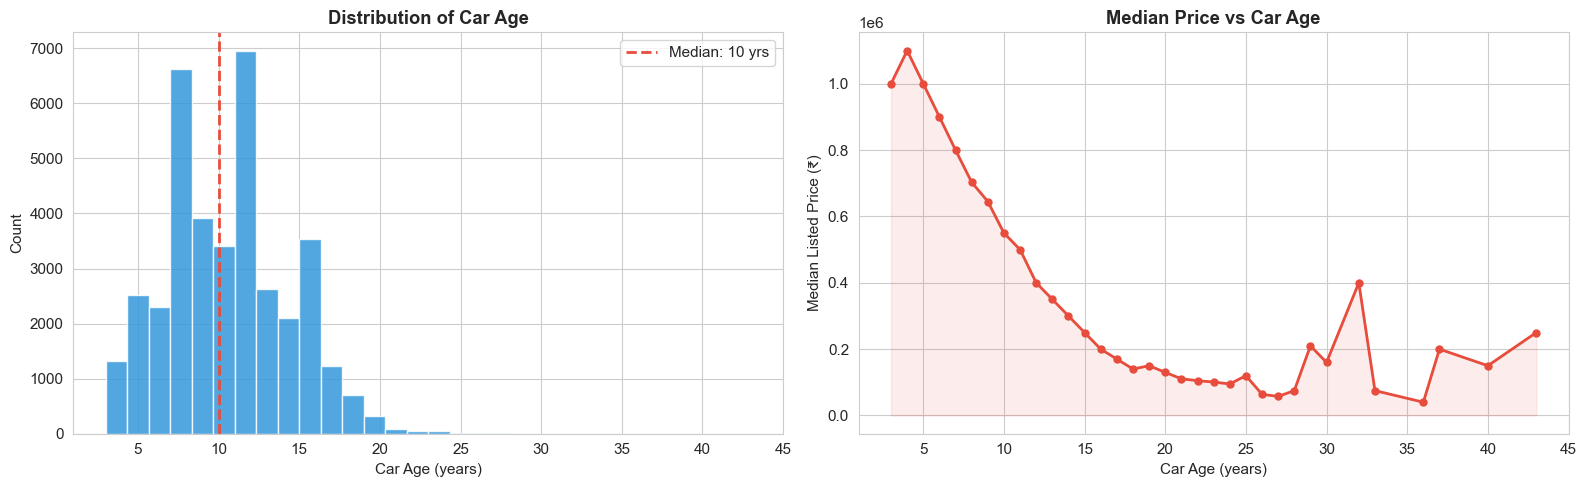

💡 Observation: As car_age increases, price decreases — confirming depreciation effect.

📸 Snapshot after: Feature Engineering (car_age)
   Shape         : 37,750 rows × 50 columns
   Missing cells : 0 (0.00%)
   Duplicates    : 0
   Memory        : 52.9 MB


In [18]:
# Visualize car_age distribution and its relationship with price
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
axes[0].hist(df['car_age'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df['car_age'].median(), color='#e74c3c', linestyle='--', lw=2,
                label=f'Median: {df["car_age"].median():.0f} yrs')
axes[0].set_title('Distribution of Car Age', fontweight='bold')
axes[0].set_xlabel('Car Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Relationship with price
age_price = df.groupby('car_age')['listed_price'].median().reset_index()
axes[1].plot(age_price['car_age'], age_price['listed_price'],
             marker='o', color='#e74c3c', linewidth=2, markersize=5)
axes[1].fill_between(age_price['car_age'], age_price['listed_price'], alpha=0.1, color='#e74c3c')
axes[1].set_title('Median Price vs Car Age', fontweight='bold')
axes[1].set_xlabel('Car Age (years)')
axes[1].set_ylabel('Median Listed Price (₹)')

plt.tight_layout()
plt.show()

print('💡 Observation: As car_age increases, price decreases — confirming depreciation effect.')

snapshot(df, 'Feature Engineering (car_age)')

---
## Step 7 — Identify Numerical & Categorical Columns

Before proceeding to outlier treatment and encoding, we need a clear separation of column types. This classification drives the next two steps.

In [19]:
# Classify columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print('📊 COLUMN TYPE CLASSIFICATION')
print('=' * 70)

print(f'\n🔢 Numerical Columns ({len(numerical_cols)}):')
print('-' * 50)
for i, col in enumerate(numerical_cols, 1):
    print(f'   {i:>2}. {col}')

print(f'\n🏷️  Categorical Columns ({len(categorical_cols)}):')
print('-' * 50)
for i, col in enumerate(categorical_cols, 1):
    nuniq = df[col].nunique()
    print(f'   {i:>2}. {col:<35} ({nuniq} unique values)')

print(f'\n   Total: {len(numerical_cols)} numerical + {len(categorical_cols)} categorical = {len(df.columns)} columns')

📊 COLUMN TYPE CLASSIFICATION

🔢 Numerical Columns (26):
--------------------------------------------------
    1. km
    2. imgCount
    3. listed_price
    4. discountValue
    5. No of Cylinder
    6. Valves per Cylinder
    7. Length
    8. Width
    9. Height
   10. Wheel Base
   11. Front Tread
   12. Rear Tread
   13. Kerb Weight
   14. Gross Weight
   15. Seats
   16. Turning Radius
   17. Top Speed
   18. Acceleration
   19. Doors
   20. Cargo Volume
   21. Alloy Wheel Size
   22. Max Power Delivered
   23. Max Power At
   24. Max Torque Delivered
   25. Max Torque At
   26. car_age

🏷️  Categorical Columns (24):
--------------------------------------------------
    1. body                                (11 unique values)
    2. transmission                        (2 unique values)
    3. fuel                                (5 unique values)
    4. oem                                 (46 unique values)
    5. model                               (382 unique values)
    6. vari

---
## Step 8 — Outlier Treatment (IQR Method)

**What are outliers?** Values that are unusually far from the majority of the data. In used car pricing, a car listed at ₹5 crore or a mileage of 1,000,000 km could be data errors or extreme edge cases.

**Why treat them?** Outliers can disproportionately affect model training, especially for linear models.

**Method — IQR (Interquartile Range):**
```
IQR = Q3 − Q1
Lower Bound = Q1 − 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR
```

**Strategy: Capping (Winsorization)** — Instead of removing outliers (which loses data), we **cap** them at the bounds. Values below the lower bound are set to the lower bound; values above the upper bound are set to the upper bound.

In [20]:
# ── Outlier Analysis: Before Treatment ──
#
# We focus on the most important numerical features for the price model.
# Columns like 'Doors' or 'Seats' have valid discrete values, so we skip them.

outlier_features = [
    'listed_price', 'km', 'car_age',
    'Kerb Weight', 'Gross Weight',
    'Length', 'Width', 'Height', 'Wheel Base',
    'Max Power Delivered', 'Max Torque Delivered',
    'Top Speed', 'Acceleration', 'Turning Radius',
    'Cargo Volume', 'Compression Ratio',
    'Ground Clearance Unladen'
]
# Keep only columns that exist
outlier_features = [c for c in outlier_features if c in df.columns]

print(f'🔍 OUTLIER ANALYSIS — IQR Method ({len(outlier_features)} features)')
print('=' * 85)
print(f'{"Feature":<30} {"Q1":>10} {"Q3":>10} {"IQR":>10} {"Lower":>10} {"Upper":>10} {"Outliers":>8} {"% Out":>6}')
print('-' * 85)

outlier_report = []
for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = outliers / len(df) * 100
    outlier_report.append((col, Q1, Q3, IQR, lower, upper, outliers, pct))
    print(f'{col:<30} {Q1:>10,.1f} {Q3:>10,.1f} {IQR:>10,.1f} {lower:>10,.1f} {upper:>10,.1f} {outliers:>8,} {pct:>5.1f}%')

print('=' * 85)

🔍 OUTLIER ANALYSIS — IQR Method (15 features)
Feature                                Q1         Q3        IQR      Lower      Upper Outliers  % Out
-------------------------------------------------------------------------------------
listed_price                    320,000.0  854,000.0  534,000.0 -481,000.0 1,655,000.0    3,238   8.6%
km                               31,759.2   83,360.0   51,600.8  -45,641.9  160,761.1      824   2.2%
car_age                               8.0       13.0        5.0        0.5       20.5      224   0.6%
Kerb Weight                       1,025.0    1,125.0      100.0      875.0    1,275.0    9,408  24.9%
Gross Weight                      1,595.0    1,595.0        0.0    1,595.0    1,595.0   16,675  44.2%
Length                            3,795.0    4,440.0      645.0    2,827.5    5,407.5        8   0.0%
Width                             1,680.0    1,790.0      110.0    1,515.0    1,955.0    4,486  11.9%
Height                            1,495.0    1,642.

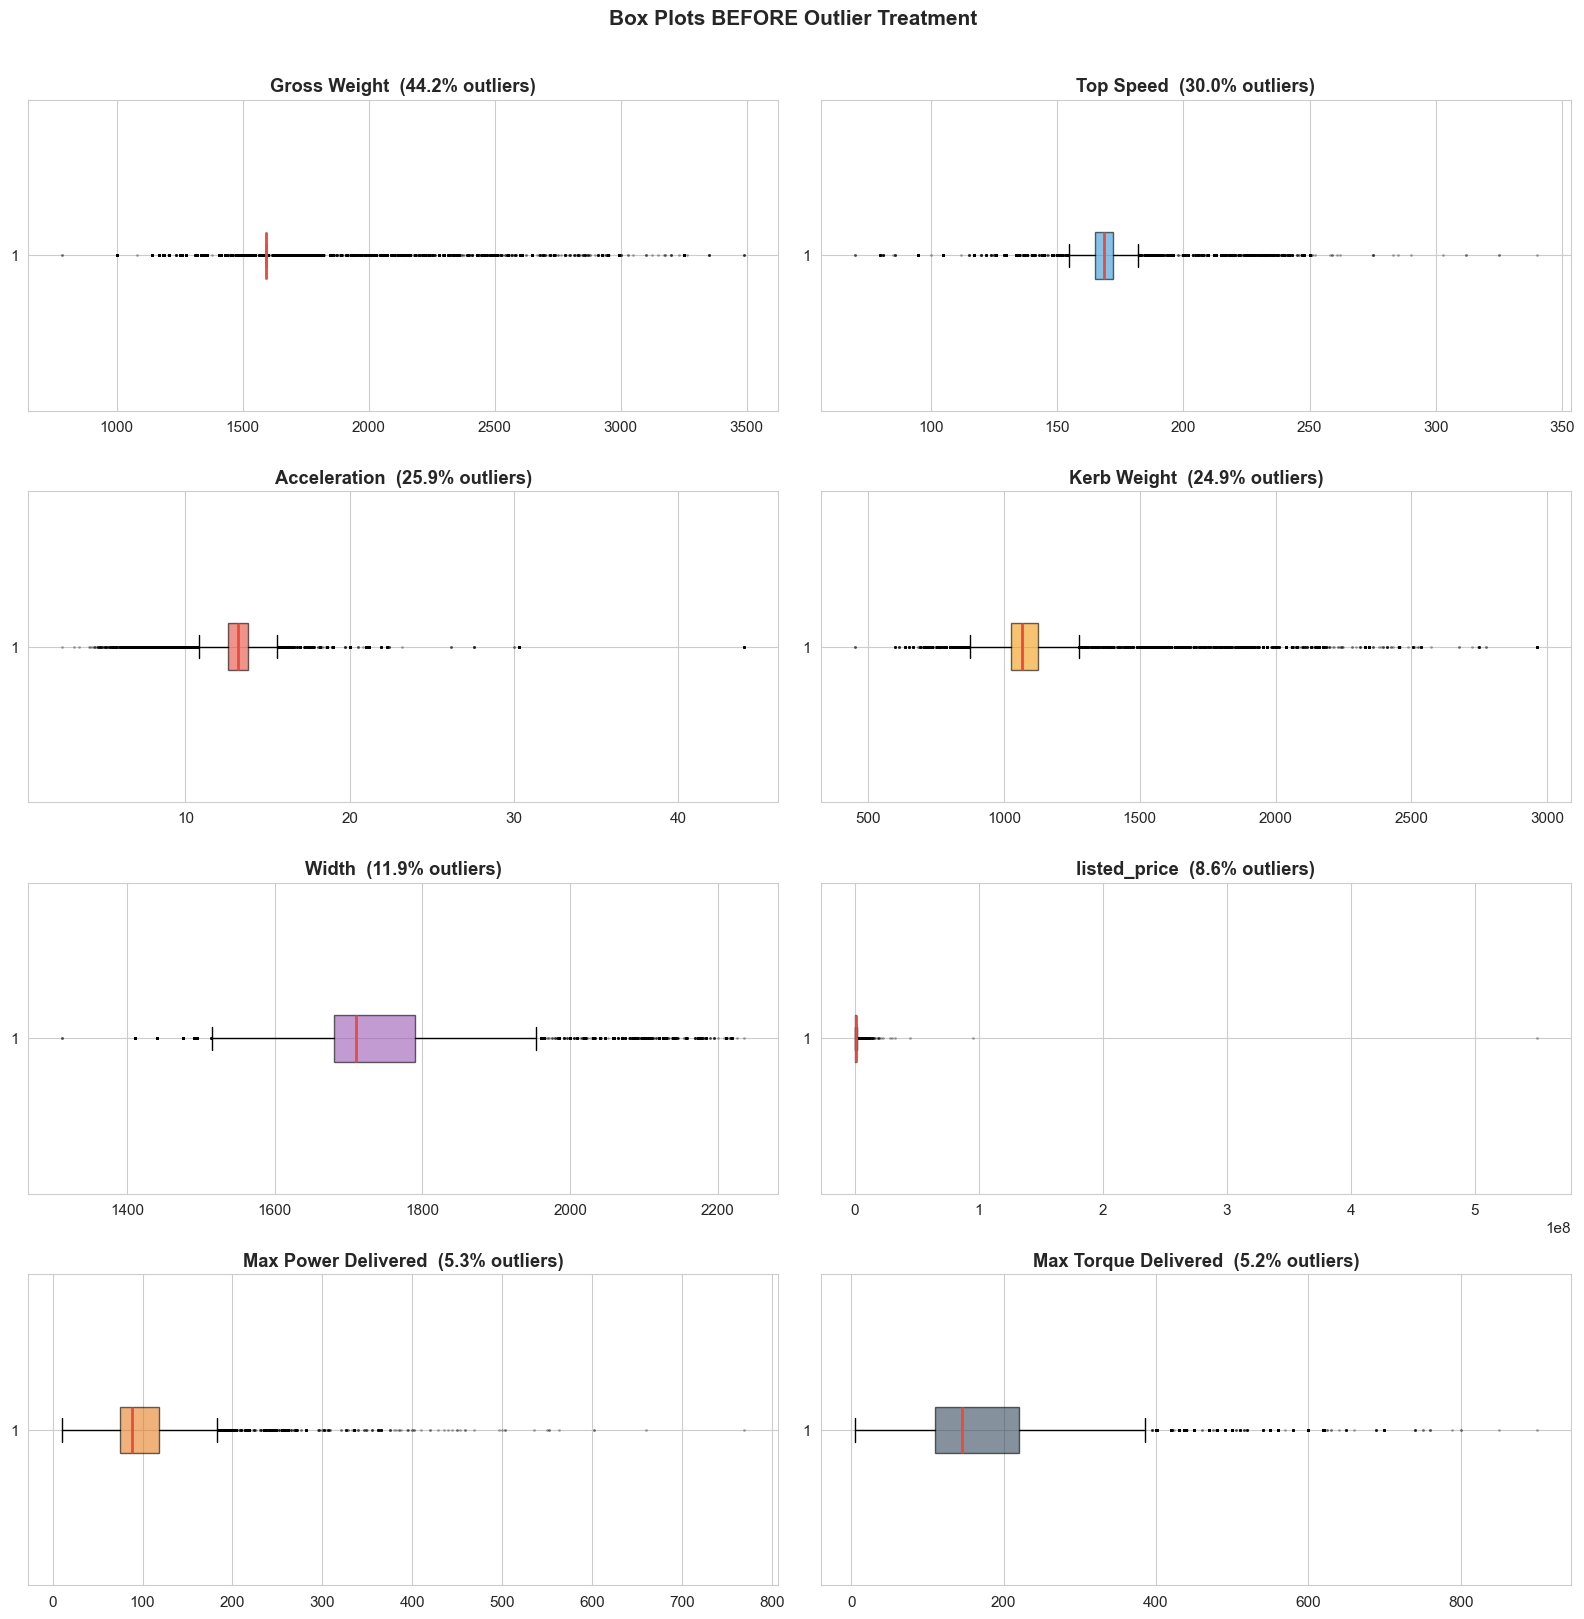

In [21]:
# ── Visualize outliers with box plots (Before treatment) ──

# Select top features with most outliers for visualization
top_outlier_features = sorted(outlier_report, key=lambda x: x[7], reverse=True)[:8]
top_outlier_cols = [x[0] for x in top_outlier_features]

n_plots = len(top_outlier_cols)
n_cols_p = 2
n_rows_p = (n_plots + 1) // 2

fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4 * n_rows_p))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    ax = axes[i]
    bp = ax.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor=COLORS[i % len(COLORS)], alpha=0.6),
                    medianprops=dict(color='#e74c3c', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    pct = [x[7] for x in outlier_report if x[0] == col][0]
    ax.set_title(f'{col}  ({pct:.1f}% outliers)', fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots BEFORE Outlier Treatment', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# ── Apply IQR Capping (Winsorization) ──

print('🔧 APPLYING IQR CAPPING...')
print('=' * 70)
print(f'{"Feature":<30} {"Capped Low":>10} {"Capped High":>12} {"Total Capped":>14}')
print('-' * 70)

for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    capped_low = (df[col] < lower).sum()
    capped_high = (df[col] > upper).sum()
    
    df[col] = df[col].clip(lower=lower, upper=upper)
    
    print(f'{col:<30} {capped_low:>10,} {capped_high:>12,} {capped_low + capped_high:>14,}')

print('=' * 70)
print('✅ Outlier capping complete.')

🔧 APPLYING IQR CAPPING...
Feature                        Capped Low  Capped High   Total Capped
----------------------------------------------------------------------
listed_price                            0        3,238          3,238
km                                      0          824            824
car_age                                 0          224            224
Kerb Weight                         4,192        5,216          9,408
Gross Weight                        8,436        8,239         16,675
Length                                  3            5              8
Width                               2,579        1,907          4,486
Height                                  6          810            816
Wheel Base                             90          571            661
Max Power Delivered                     0        2,015          2,015
Max Torque Delivered                    0        1,960          1,960
Top Speed                           4,661        6,674         

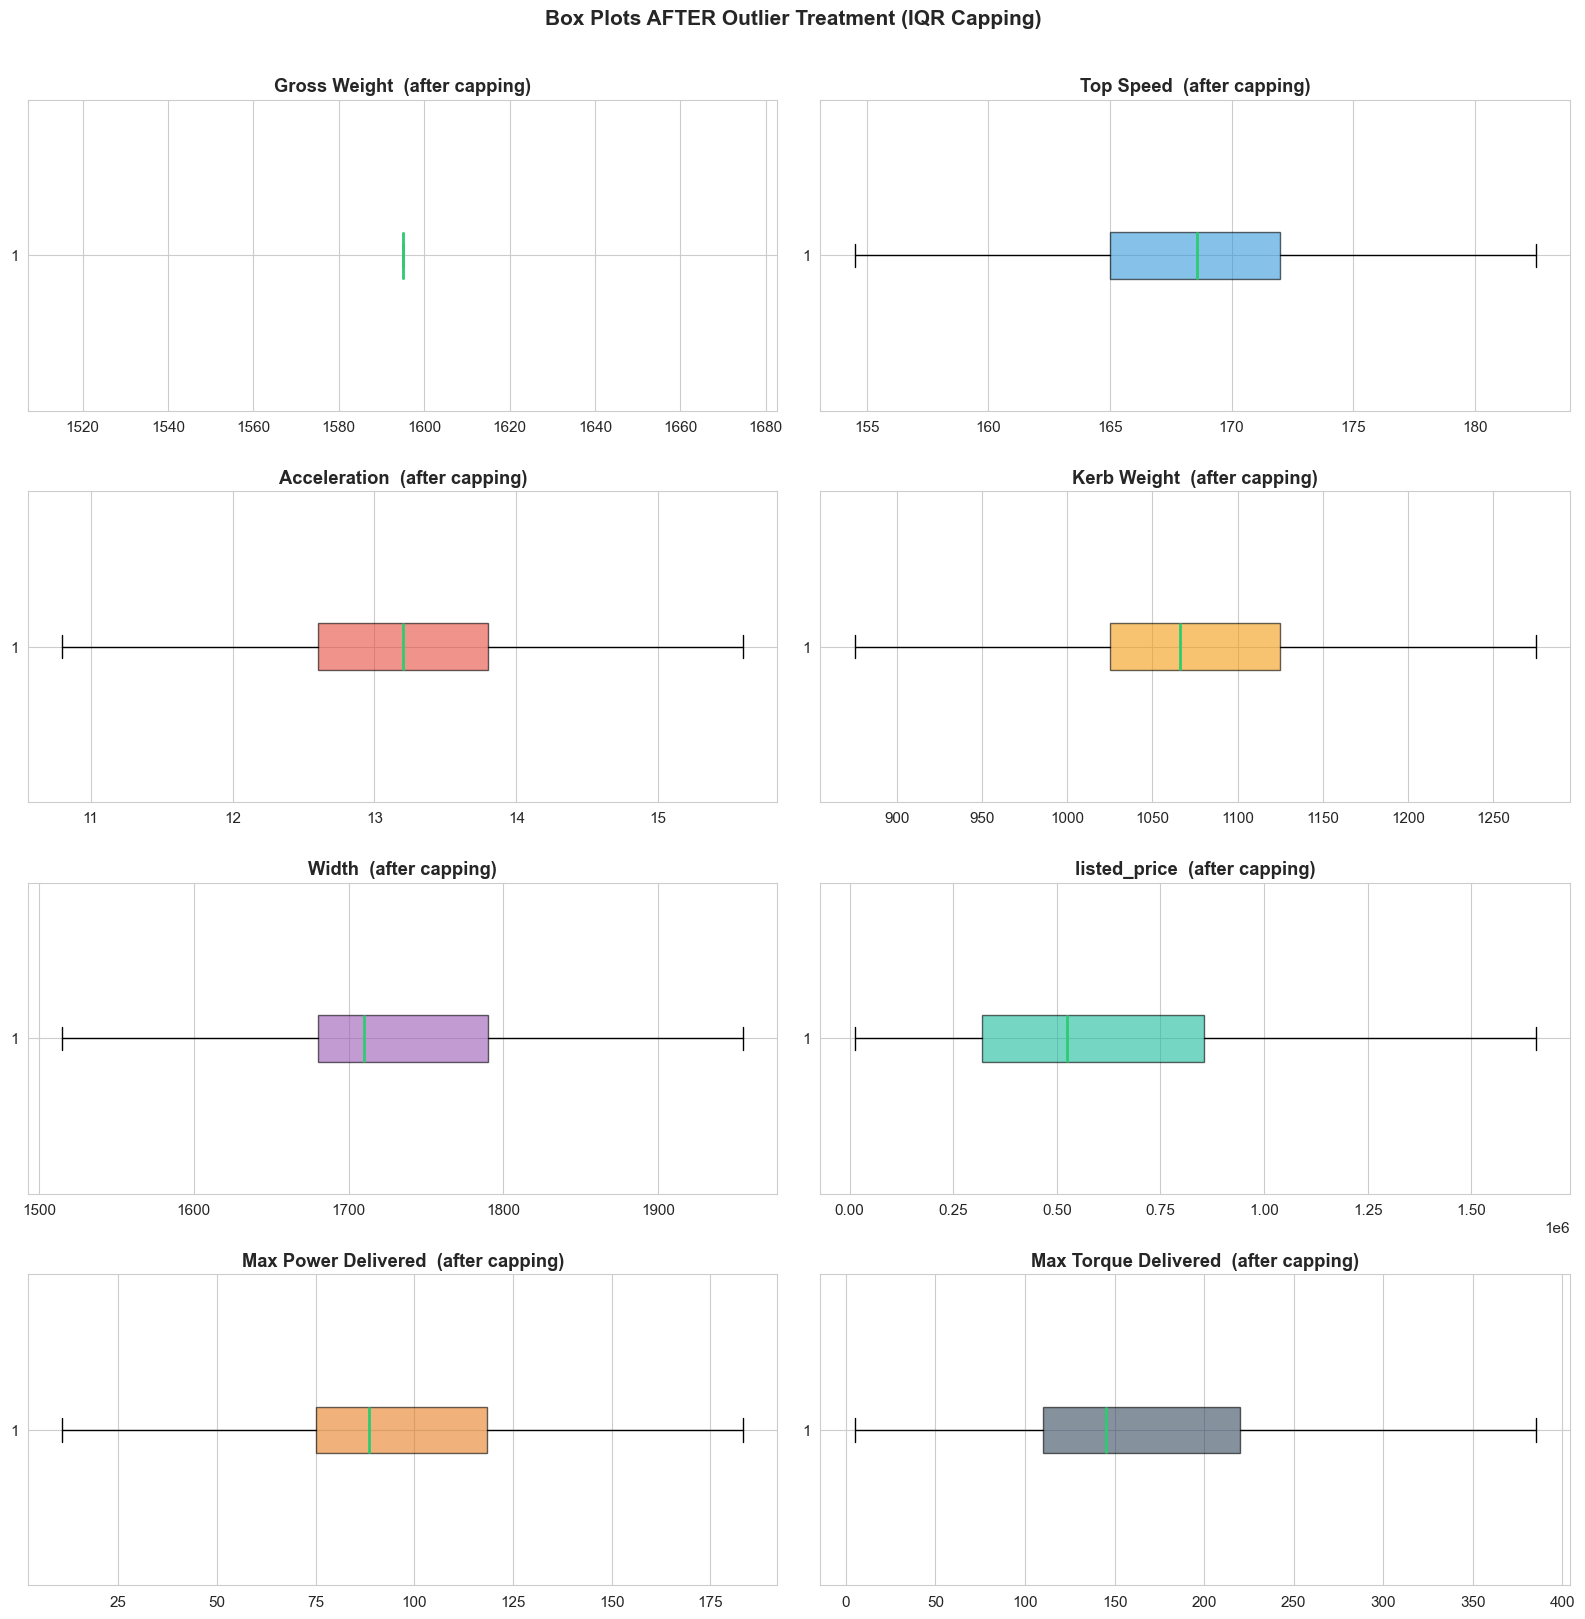

💡 Observation: Extreme values have been capped. The distributions are now tighter and more suitable for modeling.

📸 Snapshot after: Outlier Treatment (IQR Capping)
   Shape         : 37,750 rows × 50 columns
   Missing cells : 0 (0.00%)
   Duplicates    : 3
   Memory        : 52.9 MB


In [23]:
# ── Visualize box plots AFTER treatment ──

fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4 * n_rows_p))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    ax = axes[i]
    bp = ax.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor=COLORS[i % len(COLORS)], alpha=0.6),
                    medianprops=dict(color='#2ecc71', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(f'{col}  (after capping)', fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots AFTER Outlier Treatment (IQR Capping)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Observation: Extreme values have been capped. The distributions are now tighter and more suitable for modeling.')

snapshot(df, 'Outlier Treatment (IQR Capping)')

---
## Step 9 — Encode Categorical Features

Machine learning models require **numerical input**. We need to convert all categorical columns to numbers.

### Encoding Strategy

| Scenario | Technique | Reason |
|----------|-----------|--------|
| **Low cardinality** (≤ 10 unique values) | One-Hot Encoding | Creates binary columns — preserves no ordinal relationship |
| **High cardinality** (> 10 unique values) | Label Encoding | Assigns an integer to each category — avoids column explosion |

> **Why this split?** One-Hot encoding a column with 100+ unique values creates 100+ new columns (curse of dimensionality). Label encoding keeps it compact but implies an ordinal order, which is acceptable as a pragmatic trade-off for tree-based models.

In [24]:
# Refresh the categorical column list (some may have changed dtype)
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

CARDINALITY_THRESHOLD = 10

low_cardinality = [c for c in categorical_cols if df[c].nunique() <= CARDINALITY_THRESHOLD]
high_cardinality = [c for c in categorical_cols if df[c].nunique() > CARDINALITY_THRESHOLD]

print(f'🏷️  CATEGORICAL ENCODING PLAN')
print('=' * 60)
print(f'\n🟢 One-Hot Encoding (≤ {CARDINALITY_THRESHOLD} unique values): {len(low_cardinality)} columns')
for c in low_cardinality:
    print(f'   • {c:<35} ({df[c].nunique()} unique)')

print(f'\n🔵 Label Encoding (> {CARDINALITY_THRESHOLD} unique values): {len(high_cardinality)} columns')
for c in high_cardinality:
    print(f'   • {c:<35} ({df[c].nunique()} unique)')

🏷️  CATEGORICAL ENCODING PLAN

🟢 One-Hot Encoding (≤ 10 unique values): 14 columns
   • transmission                        (2 unique)
   • fuel                                (5 unique)
   • utype                               (2 unique)
   • carType                             (3 unique)
   • Valve Configuration                 (5 unique)
   • Turbo Charger                       (2 unique)
   • Super Charger                       (2 unique)
   • Drive Type                          (6 unique)
   • Steering Type                       (2 unique)
   • Front Brake Type                    (6 unique)
   • Rear Brake Type                     (6 unique)
   • Tyre Type                           (4 unique)
   • model_type_new                      (1 unique)
   • owner_type                          (6 unique)

🔵 Label Encoding (> 10 unique values): 10 columns
   • body                                (11 unique)
   • oem                                 (46 unique)
   • model                      

In [25]:
# ── One-Hot Encoding (Low Cardinality) ──

cols_before_ohe = len(df.columns)

if low_cardinality:
    # Convert booleans to string first so get_dummies handles them
    for c in low_cardinality:
        df[c] = df[c].astype(str)
    
    df = pd.get_dummies(df, columns=low_cardinality, drop_first=True, dtype=int)
    
    cols_after_ohe = len(df.columns)
    new_cols = cols_after_ohe - cols_before_ohe + len(low_cardinality)
    
    print(f'✅ One-Hot Encoding applied to {len(low_cardinality)} columns.')
    print(f'   Columns before: {cols_before_ohe} → After: {cols_after_ohe}')
    print(f'   Net new columns added: {cols_after_ohe - cols_before_ohe}')
    print(f'   (drop_first=True used to avoid multicollinearity)')
else:
    print('ℹ️  No low-cardinality columns to one-hot encode.')

✅ One-Hot Encoding applied to 14 columns.
   Columns before: 50 → After: 74
   Net new columns added: 24
   (drop_first=True used to avoid multicollinearity)


In [26]:
# ── Label Encoding (High Cardinality) ──

label_encoders = {}   # Store encoders for potential inverse transform later

if high_cardinality:
    print(f'🔵 LABEL ENCODING:')
    print(f'{"Column":<35} {"Unique Before":>15} {"Encoded Range":>15}')
    print('-' * 65)
    
    for col in high_cardinality:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = df[col].astype(str)
            df[col] = le.fit_transform(df[col])
            label_encoders[col] = le
            print(f'{col:<35} {len(le.classes_):>15} {f"0 → {len(le.classes_) - 1}":>15}')
    
    print('-' * 65)
    print(f'✅ Label Encoding applied to {len(high_cardinality)} columns.')
    print(f'   Encoders stored in label_encoders dict for inverse transform if needed.')
else:
    print('ℹ️  No high-cardinality columns to label encode.')

🔵 LABEL ENCODING:
Column                                Unique Before   Encoded Range
-----------------------------------------------------------------
body                                             11          0 → 10
oem                                              46          0 → 45
model                                           382         0 → 381
variant                                        3430        0 → 3429
City                                            617         0 → 616
Engine Type                                     566         0 → 565
Gear Box                                         11          0 → 10
state                                            33          0 → 32
exterior_color                                  747         0 → 746
Fuel Suppy System                                14          0 → 13
-----------------------------------------------------------------
✅ Label Encoding applied to 10 columns.
   Encoders stored in label_encoders dict for inverse transfor

In [27]:
snapshot(df, 'Categorical Encoding')


📸 Snapshot after: Categorical Encoding
   Shape         : 37,750 rows × 74 columns
   Missing cells : 0 (0.00%)
   Duplicates    : 3
   Memory        : 21.3 MB


---
## Step 10 — Final Validation: Model-Readiness Check

Before saving, we verify that the dataset is fully ready for machine learning:
- ✅ No missing values
- ✅ No object/string columns
- ✅ No duplicate rows
- ✅ Target variable present

In [28]:
print('🏁 FINAL VALIDATION — MODEL-READINESS CHECK')
print('=' * 60)

# Check 1: Missing values
total_missing = df.isnull().sum().sum()
status_1 = '✅ PASS' if total_missing == 0 else '❌ FAIL'
print(f'{status_1}  Missing values         : {total_missing}')

# Check 2: No object columns
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
status_2 = '✅ PASS' if len(obj_cols) == 0 else '❌ FAIL'
print(f'{status_2}  Object/String columns  : {len(obj_cols)}')
if obj_cols:
    print(f'           Remaining: {obj_cols}')

# Check 3: No duplicates
dup_count = df.duplicated().sum()
status_3 = '✅ PASS' if dup_count == 0 else '⚠️  WARN'
print(f'{status_3}  Duplicate rows         : {dup_count}')

# Check 4: Target variable exists
status_4 = '✅ PASS' if 'listed_price' in df.columns else '❌ FAIL'
print(f'{status_4}  Target (listed_price)  : {"Present" if "listed_price" in df.columns else "MISSING!"}')

# Check 5: All numeric
all_numeric = all(dtype.kind in ('i', 'f', 'u', 'b') for dtype in df.dtypes)
status_5 = '✅ PASS' if all_numeric else '❌ FAIL'
print(f'{status_5}  All features numeric   : {all_numeric}')

print('=' * 60)
all_pass = total_missing == 0 and len(obj_cols) == 0 and 'listed_price' in df.columns and all_numeric
if all_pass:
    print('\n🎉 DATASET IS MODEL-READY!')
else:
    print('\n⚠️  Some checks failed — review the issues above before proceeding.')

🏁 FINAL VALIDATION — MODEL-READINESS CHECK
✅ PASS  Missing values         : 0
✅ PASS  Object/String columns  : 0
⚠️  WARN  Duplicate rows         : 3
✅ PASS  Target (listed_price)  : Present
✅ PASS  All features numeric   : True

🎉 DATASET IS MODEL-READY!


---
## Step 11 — Final Summary & Save Processed Dataset

In [29]:
# ── Final dataset overview ──

print('📊 FINAL DATASET SUMMARY')
print('=' * 70)
print(f'   Original shape  : {initial_shape[0]:,} rows × {initial_shape[1]} columns')
print(f'   Final shape     : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Rows removed    : {initial_shape[0] - df.shape[0]:,}')
print(f'   Columns changed : {initial_shape[1]} → {df.shape[1]} (dropped some, added one-hot & car_age)')
print(f'   Missing values  : {df.isnull().sum().sum()}')
print(f'   Memory usage    : {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB')
print('=' * 70)

📊 FINAL DATASET SUMMARY
   Original shape  : 37,813 rows × 66 columns
   Final shape     : 37,750 rows × 74 columns
   Rows removed    : 63
   Columns changed : 66 → 74 (dropped some, added one-hot & car_age)
   Missing values  : 0
   Memory usage    : 21.3 MB


In [30]:
# ── Data types summary ──

dtype_counts = df.dtypes.value_counts()
print('\n📋 DATA TYPES:')
for dtype, count in dtype_counts.items():
    print(f'   {str(dtype):<15} : {count} columns')
print(f'   {"TOTAL":<15} : {len(df.columns)} columns')


📋 DATA TYPES:
   int64           : 50 columns
   float64         : 24 columns
   TOTAL           : 74 columns


In [31]:
# ── Missing values confirmation ──

final_missing = df.isnull().sum()
final_missing = final_missing[final_missing > 0]

if len(final_missing) == 0:
    print('✅ CONFIRMED: Zero missing values across all columns.')
else:
    print(f'⚠️  {len(final_missing)} column(s) still have missing values:')
    print(final_missing)

✅ CONFIRMED: Zero missing values across all columns.


In [32]:
# ── Quick look at the final processed data ──

print('\n🔍 Final Data Preview (first 5 rows):')
df.head()


🔍 Final Data Preview (first 5 rows):


,body,km,imgCount,oem,model,variant,City,listed_price,discountValue,Engine Type,No of Cylinder,Valves per Cylinder,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Seats,Turning Radius,Top Speed,Acceleration,Doors,Cargo Volume,state,exterior_color,Fuel Suppy System,Alloy Wheel Size,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At,car_age,transmission_manual,fuel_diesel,fuel_electric,fuel_lpg,fuel_petrol,utype_individual,carType_corporate,carType_partner,Valve Configuration_dohc,Valve Configuration_idsi,Valve Configuration_ohv / pushrod,Valve Configuration_sohc,Turbo Charger_True,Super Charger_True,Drive Type_4wd,Drive Type_4x2,Drive Type_awd,Drive Type_fwd,Drive Type_rwd,Steering Type_power,Front Brake Type_carbon ceramic,Front Brake Type_disc,Front Brake Type_disc & drum,Front Brake Type_drum,Front Brake Type_ventilated disc,Rear Brake Type_carbon ceramic,Rear Brake Type_disc,Rear Brake Type_disc & drum,Rear Brake Type_drum,Rear Brake Type_ventilated disc,Tyre Type_tube,Tyre Type_tubeless,Tyre Type_tubeless radial,owner_type_first,owner_type_fourth,owner_type_second,owner_type_third,owner_type_unregistered car
0,2,"69,162.00",15,29,223,2179,339,"370,000.00",0,345,3.00,4.00,"3,599.00","1,515.00","1,700.00","2,400.00","1,295.00","1,290.00",960.00,"1,595.00",3,5.00,4.60,154.50,15.60,5.00,180.00,30,621,10,16.00,58.16,"6,200.00",77.00,"3,500.00",10.00,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0
1,2,"45,864.00",15,29,197,1926,379,"365,000.00",0,345,3.00,4.00,"3,600.00","1,600.00","1,560.00","2,425.00","1,420.00","1,410.00",915.00,"1,595.00",3,5.00,4.70,154.50,15.05,5.00,235.00,18,277,7,16.00,58.20,"6,000.00",78.00,"3,500.00",11.00,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0
2,8,"81,506.00",15,15,85,2559,409,"421,000.00",0,316,4.00,4.00,"3,990.00","1,680.00","1,505.00","2,405.00","1,485.00","1,493.00",950.00,"1,595.00",3,5.00,4.50,160.00,15.00,4.00,400.00,8,621,10,16.00,86.70,"6,000.00",109.00,"4,500.00",11.00,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
3,2,"115,893.00",0,29,223,2179,409,"240,000.00",0,340,3.00,4.00,"3,595.00","1,515.00","1,700.00","2,400.00","1,295.00","1,290.00",960.00,"1,595.00",3,5.00,4.60,168.56,13.20,4.00,350.00,8,621,10,13.00,58.20,"6,200.00",77.00,"3,500.00",13.00,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0
4,6,"18,900.00",6,29,204,3075,379,"1,175,000.00",0,359,4.00,4.00,"4,395.00","1,735.00","1,690.00","2,740.00","1,485.00","1,493.00","1,250.00","1,595.00",3,7.00,5.20,168.56,13.20,5.00,350.00,18,737,10,16.00,86.63,"5,500.00",121.50,"4,200.00",4.00,1,0,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0


In [33]:
# ── Descriptive statistics of the final dataset ──

print('\n📈 Final Descriptive Statistics:')
df.describe().T


📈 Final Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
body,"37,750.00",5.72,3.13,0.00,2.00,8.00,9.00,10.00
km,"37,750.00","61,047.88","37,245.74",101.00,"31,759.25","56,767.00","83,360.00","160,761.12"
imgCount,"37,750.00",15.58,8.36,0.00,10.00,15.00,21.00,74.00
oem,"37,750.00",24.90,10.79,0.00,17.00,26.00,29.00,45.00
model,"37,750.00",177.55,92.51,0.00,101.00,184.00,223.00,381.00
...,...,...,...,...,...,...,...,...
owner_type_first,"37,750.00",0.70,0.46,0.00,0.00,1.00,1.00,1.00
owner_type_fourth,"37,750.00",0.01,0.11,0.00,0.00,0.00,0.00,1.00
owner_type_second,"37,750.00",0.23,0.42,0.00,0.00,0.00,0.00,1.00
owner_type_third,"37,750.00",0.05,0.22,0.00,0.00,0.00,0.00,1.00


In [34]:
# ── Save the processed dataset ──

OUTPUT_FILENAME = 'preprocessed_car_data.csv'
OUTPUT_PATH = os.path.join(NOTEBOOK_DIR, OUTPUT_FILENAME)

if not os.path.exists(os.path.dirname(OUTPUT_PATH)):
    OUTPUT_PATH = os.path.join(r'd:\MLPs\Used Car Price Prediction & Valuation System', OUTPUT_FILENAME)

df.to_csv(OUTPUT_PATH, index=False)

# Verify the saved file
saved_size = os.path.getsize(OUTPUT_PATH) / (1024**2)
print(f'💾 DATASET SAVED SUCCESSFULLY!')
print(f'   File: {OUTPUT_PATH}')
print(f'   Size: {saved_size:.1f} MB')
print(f'   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

💾 DATASET SAVED SUCCESSFULLY!
   File: d:\MLPs\Used Car Price Prediction & Valuation System\preprocessed_car_data.csv
   Size: 9.5 MB
   Rows: 37,750  |  Columns: 74


---
## 📌 Preprocessing Summary & Conclusions

### What was done:

| Step | Action | Details |
|------|--------|---------|
| 1 | **Loaded data** | Raw CSV with 66 columns |
| 2 | **Dropped high-missing columns** | Removed columns with > 60% null values — too sparse to impute reliably |
| 3 | **Removed unnecessary columns** | Dropped IDs (`usedCarSkuId`), image URLs, text feature lists, redundant fields (`loc`, `Color`, `dvn`) |
| 4 | **Imputed missing values** | Numerical → Median (robust to outliers); Categorical → Mode (most frequent value) |
| 5 | **Removed duplicates** | Dropped exact duplicate rows to prevent model bias |
| 6 | **Engineered `car_age`** | Created `car_age = current_year − myear` and dropped `myear` — time-invariant depreciation feature |
| 7 | **Classified columns** | Separated numerical and categorical columns for targeted treatment |
| 8 | **Treated outliers** | IQR capping (winsorization) on key numerical features — preserves data while limiting extremes |
| 9 | **Encoded categoricals** | Low-cardinality (≤10) → One-Hot Encoding; High-cardinality (>10) → Label Encoding |
| 10 | **Validated** | Zero nulls, all numeric, target present, no object columns |
| 11 | **Saved** | Output: `preprocessed_car_data.csv` |

### Key Decisions & Rationale:

- **Median over Mean for imputation:** Car prices and mileage are right-skewed — median is robust to these outliers.
- **Capping over Removal for outliers:** Removing outliers loses data; capping retains the row while bounding extreme values.
- **Label Encoding for high-cardinality:** One-hot encoding columns with 50+ categories would create a very sparse, wide dataset. Label encoding is a practical trade-off, especially for tree-based models (Random Forest, XGBoost).
- **`drop_first=True` in One-Hot Encoding:** Prevents multicollinearity (the dummy variable trap) in linear models.

### Next Steps:
1. **Feature Selection** — Identify and keep only the most predictive features
2. **Train-Test Split** — Split data for model training and evaluation
3. **Model Building** — Train regression models (Linear Regression, Random Forest, XGBoost, etc.)

---
*Preprocessing complete. The dataset is now clean, encoded, and ready for model training.*